#### SALES ANALYTICS

StyleSense is a growing clothing retail company that sells Men's, Women's, and Kids' clothing across Physical stores and Online channels. Like many retail businesses today, StyleSense faces growing competition from large e-commerce platforms and needs to make smarter, data-driven decisions to stay profitable.

#### Business Problem

Despite consistent sales, StyleSense's :

- Profit margins are unclear – cost of goods, payroll, rent, and marketing all eat into revenue.
- Seasonality is not being planned for – winter and summer products go out of stock or sit unsold.
- Promotions and discounts are used freely – but no one knows if they're actually generating profit.
- Customer segments are not being leveraged – VIP customers may be leaving due to lack of retention programs.
- Online vs physical performance is unknown – marketing spend may be mis-allocated.

#### Project Objective

This project analyzes 18 months (Jan 2024 – Jun 2025) of sales, customer, inventory, and expense data to:

- Understand what has been selling and who is buying (Descriptive).
- Diagnose why performance is the way it is (Diagnostic).
- Predict future revenue trends (Predictive).
- Recommend clear actions management can take to improve ROI (Prescriptive).

#### Data Understanding

- clothing_sales.csv(10,000 rows)-every transaction: product, channel, price, discount, profit.
- clothing_customers.csv(200 rows)-customer profiles: demographics, segments, purchase history.
- clothing_expenses.csv(1,300 rows)-business costs by category (rent, payroll, COGS, marketing).
- clothing_inventory.csv(13,600 rows)-daily stock levels per product with reorder triggers.
- clothing_products.csv(25 rows)-product master list with base price and cost.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Chart styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

BLUE   = '#3498DB'
GREEN  = '#27AE60'
RED    = '#E74C3C'
ORANGE = '#E67E22'
PURPLE = '#8E44AD'
GOLD   = '#F39C12'
TEAL   = '#1ABC9C'
GREY   = '#95A5A6'


In [3]:
# Load all five datasets
sales     = pd.read_csv('clothing_sales.csv')
customers = pd.read_csv('clothing_customers.csv')
expenses  = pd.read_csv('clothing_expenses.csv')
inventory = pd.read_csv('clothing_inventory.csv')
products  = pd.read_csv('clothing_products.csv')

In [4]:
print(f'  Sales rows:      {len(sales):,}')
print(f'  Customer rows:   {len(customers):,}')
print(f'  Expense rows:    {len(expenses):,}')
print(f'  Inventory rows:  {len(inventory):,}')
print(f'  Product rows:    {len(products):,}')

  Sales rows:      10,039
  Customer rows:   200
  Expense rows:    1,322
  Inventory rows:  13,675
  Product rows:    25


In [5]:
#Examine sales data structure
#Looking at the last few rows gives me a sense of: what columns exist,data types (dates, numbers, categories),data quality (any obvious nulls or errors)
#and the most recent transactions (end of June 2025)
sales.tail()

,sale_id,date,store_channel,payment_method,product_id,product_name,category,sub_category,quantity_sold,unit_price,discount_pct,discount_amount,total_sale,cost_total,gross_profit,customer_id,is_promotion,is_returned
10034,S01581,2024-03-22,Physical,Credit Card,P010,Women's Blouse,Women,Top,3,34.99,10,3.5,94.47,36.0,58.47,C124,True,True
10035,S05467,2024-10-29,Physical,Debit Card,P021,Unisex Socks (3-pack),All,Accessories,1,9.99,15,1.5,8.49,2.5,5.99,C053,False,False
10036,S06941,2025-01-11,Online,PayPal,P006,Men's Puffer Jacket,Men,Jacket,2,89.99,0,0.0,179.98,70.0,109.98,C052,False,False
10037,S06299,2024-12-17,Online,Debit Card,P021,Unisex Socks (3-pack),All,Accessories,2,9.99,5,0.5,18.98,5.0,13.98,C073,False,False
10038,S00246,2024-01-07,Online,PayPal,P020,Unisex Cap,All,Accessories,3,14.99,0,0.0,44.97,12.0,32.97,C111,True,False


#####  Data Cleaning_ Sales_csv

In [6]:
#Check for missing values
sales.isnull().sum()

sale_id              0
date                 0
store_channel        0
payment_method       5
product_id           0
product_name         0
category             0
sub_category         0
quantity_sold        0
unit_price           0
discount_pct         0
discount_amount      0
total_sale           0
cost_total           0
gross_profit         0
customer_id        101
is_promotion         0
is_returned          0
dtype: int64

There are :
- 5 missing payment_methods
- 101 missing customer_ids

In [7]:
#check for nulls in sale_id column
sales.sale_id.isnull().sum()

np.int64(0)

In [8]:
#check for duplicates in sale_id column
sales['sale_id'].duplicated().sum()

np.int64(50)

- There are 50 duplicated ids in sales_id column.

In [9]:
# See the duplicate rows
dupes = sales[sales['sale_id'].duplicated(keep=False)].sort_values('sale_id')
print(dupes[['sale_id', 'date', 'customer_id', 'product_id', 'quantity_sold', 'total_sale']].head(20))

      sale_id        date customer_id product_id  quantity_sold  total_sale
32     S00033  2024-01-02        C150       P020              1       11.99
9993   S00033  2024-01-02        C150       P020              1       11.99
145    S00146  2024-01-04        C047       P018              1       38.24
10020  S00146  2024-01-04        C047       P018              1       38.24
10038  S00246  2024-01-07        C111       P020              3       44.97
245    S00246  2024-01-07        C111       P020              3       44.97
248    S00249  2024-01-07        C028       P023              1       23.74
9989   S00249  2024-01-07        C028       P023              1       23.74
10031  S00273  2024-01-07        C200       P013              3      152.97
272    S00273  2024-01-07        C200       P013              3      152.97
816    S00817  2024-02-10        C179       P005              3      170.97
10004  S00817  2024-02-10        C179       P005              3      170.97
1033   S0103

- The duplicates appear to be exact duplicates,suggesting a system glitch during data export. So i remove duplicates and I keep='first' to preserve one copy of each transaction.
This reduces my dataset from 10,039 to 9,989 rows - a 50-row reduction.

In [10]:
# drop duplicates
sales = sales.drop_duplicates(subset='sale_id', keep='first')
print(sales.shape)

(9989, 18)


In [11]:
#check customer_id column
sales.customer_id

0       C032
1       C151
2       C010
3       C017
4       C089
        ... 
9984    C052
9985    C105
9986    C109
9987    C028
9988    C143
Name: customer_id, Length: 9989, dtype: str

In [12]:
# check for duplicates
sales.customer_id.duplicated().sum()

np.int64(9788)

- The duplicated values in customer_id are likely to be because a customer can make purchases in different days, making them a repeat client.

In [13]:
# check column names
sales.columns

Index(['sale_id', 'date', 'store_channel', 'payment_method', 'product_id',
       'product_name', 'category', 'sub_category', 'quantity_sold',
       'unit_price', 'discount_pct', 'discount_amount', 'total_sale',
       'cost_total', 'gross_profit', 'customer_id', 'is_promotion',
       'is_returned'],
      dtype='str')

In [14]:
# check for column data types
sales.dtypes

sale_id                str
date                   str
store_channel          str
payment_method         str
product_id             str
product_name           str
category               str
sub_category           str
quantity_sold        int64
unit_price         float64
discount_pct         int64
discount_amount    float64
total_sale         float64
cost_total         float64
gross_profit       float64
customer_id            str
is_promotion          bool
is_returned           bool
dtype: object

In [15]:
# convert date column ino data data type
sales.date= pd.to_datetime(sales['date'])

In [16]:
# convert all string columns to object data type
str_cols = sales.select_dtypes(include='string').columns
sales[str_cols] = sales[str_cols].astype(object)
sales.dtypes

sale_id                    object
date               datetime64[us]
store_channel              object
payment_method             object
product_id                 object
product_name               object
category                   object
sub_category               object
quantity_sold               int64
unit_price                float64
discount_pct                int64
discount_amount           float64
total_sale                float64
cost_total                float64
gross_profit              float64
customer_id                object
is_promotion                 bool
is_returned                  bool
dtype: object

In [17]:
#statistical view of date column
sales.date.describe()

count                          9989
mean     2024-09-28 10:34:43.812193
min             2024-01-01 00:00:00
25%             2024-05-15 00:00:00
50%             2024-09-29 00:00:00
75%             2025-02-11 00:00:00
max             2025-06-30 00:00:00
Name: date, dtype: object

In [18]:
sales['date'].value_counts() 

date
2024-08-22    50
2024-01-06    49
2025-01-01    49
2025-06-03    49
2025-06-04    49
              ..
2025-04-09     8
2025-05-01     8
2025-06-12     8
2025-06-20     8
2025-06-23     8
Name: count, Length: 547, dtype: int64

In [19]:
sales['date'].duplicated().sum() 

np.int64(9442)

In [20]:
# Check sales count per day to spot any suspicious gaps
sales.groupby('date').size().sort_values() 

date
2025-06-12     8
2024-02-06     8
2025-02-20     8
2024-01-08     8
2025-01-15     8
              ..
2025-01-01    49
2024-01-06    49
2025-06-03    49
2025-06-04    49
2024-08-22    50
Length: 547, dtype: int64

In [21]:
# Check if any dates fall on unexpected days (e.g. if store is closed on certain days)
sales['date'].dt.dayofweek.value_counts()

date
5    1871
6    1833
4    1295
3    1266
0    1244
1    1244
2    1236
Name: count, dtype: int64

- All days have sales, but weekends (5,6) have highest volume. This makes sense for retail and validates data quality.

In [22]:
sales[sales['date'] == '']  

,sale_id,date,store_channel,payment_method,product_id,product_name,category,sub_category,quantity_sold,unit_price,discount_pct,discount_amount,total_sale,cost_total,gross_profit,customer_id,is_promotion,is_returned


In [23]:
#Analyze discount patterns
sales['discount_pct'].value_counts()

discount_pct
0     4489
5     2189
10    1829
15    1127
20     355
Name: count, dtype: int64

- Discounts are in 5% increments (0,5,10,15,20%).
- This suggests standardized promotions rather than arbitrary discounts.
- 0% discounts (4,489 transactions) might be full-price sales or non-promotional items.

##### Validate and correct financial calculations

In [24]:
# Check if discount was calculated per unit instead of total
sales['discount_check_unit'] = (sales['unit_price'] * sales['discount_pct'] / 100).round(2)
sales[sales['discount_check_unit'] != sales['discount_amount']][['unit_price', 'quantity_sold', 'discount_pct', 'discount_amount', 'discount_check_unit']].head(10)

,unit_price,quantity_sold,discount_pct,discount_amount,discount_check_unit


In [25]:
sales['discount_pct'].describe()

count    9989.000000
mean        5.329863
std         5.914879
min         0.000000
25%         0.000000
50%         5.000000
75%        10.000000
max        20.000000
Name: discount_pct, dtype: float64

##### Recalculate financial metrics

In [26]:
sales['discount_amount'] = (sales['unit_price'] * sales['quantity_sold'] * sales['discount_pct'] / 100).round(2)

In [27]:
sales['total_sale'] = (sales['unit_price'] * sales['quantity_sold'] - sales['discount_amount']).round(2)
sales['gross_profit'] = (sales['total_sale'] - sales['cost_total']).round(2)

In [28]:
# discount_amount should be unit_price * quantity * discount_pct/100
sales['discount_check'] = (sales['unit_price'] * sales['quantity_sold'] * sales['discount_pct'] / 100).round(2)
sales[sales['discount_check'] != sales['discount_amount']]

# gross_profit should be total_sale - cost_total
sales['profit_check'] = (sales['total_sale'] - sales['cost_total']).round(2)
sales[sales['profit_check'] != sales['gross_profit']]

,sale_id,date,store_channel,payment_method,product_id,product_name,category,sub_category,quantity_sold,unit_price,...,discount_amount,total_sale,cost_total,gross_profit,customer_id,is_promotion,is_returned,discount_check_unit,discount_check,profit_check


In [29]:
# drop the temporary columns
sales.drop(columns=['discount_check', 'discount_check_unit', 'profit_check'], inplace=True)

In [30]:
#check column payment_method
sales.payment_method

0        Debit Card
1        Debit Card
2       Credit Card
3              Cash
4       Credit Card
           ...     
9984     Debit Card
9985    Credit Card
9986    Credit Card
9987    Credit Card
9988     Debit Card
Name: payment_method, Length: 9989, dtype: object

In [31]:
#check for nique values in this column
sales.payment_method.unique()

array(['Debit Card', 'Credit Card', 'Cash', 'Mobile Pay', 'PayPal', nan],
      dtype=object)

In [32]:
#Handle missing payment methods
sales.loc[sales['payment_method'].isna(), 'payment_method'] = 'Unknown'


In [33]:
#Handle missing customer_ids
sales.loc[sales['customer_id'].isna(), 'customer_id'] = 'Guest'

There are 101 missing values in customer_id column and could mean:
- Walk-in customers not in loyalty program.
- Online guest checkouts.
- Data entry errors.

So filling with 'Guest' category lets me analyze these separately without losing sales data.

In [34]:
# Verify all nulls handled
sales.isnull().sum()

sale_id            0
date               0
store_channel      0
payment_method     0
product_id         0
product_name       0
category           0
sub_category       0
quantity_sold      0
unit_price         0
discount_pct       0
discount_amount    0
total_sale         0
cost_total         0
gross_profit       0
customer_id        0
is_promotion       0
is_returned        0
dtype: int64

In [35]:
#Save cleaned data
sales.to_csv('sales_clean_data.csv', index=False)

#### Data Cleaning_ customers_csv

In [36]:
customers.head()

,customer_id,name,email,age,gender,city,state,segment,total_items_purchased,total_spent,num_orders,last_purchase_date,favourite_category,first_purchase_date,avg_order_value
0,C001,Sandra Lewis,sandra.lewis1@yahoo.com,40,F,Nashville,TN,New,83,3108.42,57,2025-06-18,Women,2024-01-29,54.53
1,C002,Kimberly Martinez,kimberly.martinez98@outlook.com,33,F,Charlotte,NC,Loyal,176,6903.24,67,2025-06-25,Women,2024-01-03,103.03
2,C003,Susan Thompson,susan.thompson78@outlook.com,42,F,Atlanta,GA,Seasonal,67,2501.08,43,2025-06-20,Women,2024-01-12,58.16
3,C004,Anna Davis,anna.davis11@icloud.com,53,F,Minneapolis,MN,Occasional,76,2777.74,48,2025-06-26,Women,2024-01-06,57.87
4,C005,Pamela Gonzalez,pamela.gonzalez6@yahoo.com,32,F,Phoenix,AZ,Seasonal,95,3634.30,60,2025-06-23,Women,2024-01-09,60.57


In [37]:
customers.tail()

,customer_id,name,email,age,gender,city,state,segment,total_items_purchased,total_spent,num_orders,last_purchase_date,favourite_category,first_purchase_date,avg_order_value
195,C196,Brenda Roberts,brenda.roberts78@outlook.com,39,F,Los Angeles,CA,Loyal,135,5587.90,51,2025-06-04,Women,2024-01-05,109.57
196,C197,Rachel Carter,rachel.carter44@outlook.com,24,F,Portland,OR,Loyal,149,6037.76,57,2025-06-09,Women,2024-01-01,105.93
197,C198,Raymond Nelson,raymond.nelson9@yahoo.com,36,M,Tampa,FL,New,65,2362.35,44,2025-06-29,Men,2024-01-03,53.69
198,C199,David Mitchell,david.mitchell49@hotmail.com,35,M,Charlotte,NC,Occasional,79,2723.71,54,2025-06-14,Men,2024-01-02,50.44
199,C200,Jason Martin,jason.martin73@icloud.com,21,M,Las Vegas,NV,Loyal,121,4141.79,48,2025-06-26,Men,2024-01-06,86.29


In [38]:
customers.dtypes

customer_id                  str
name                         str
email                        str
age                        int64
gender                       str
city                         str
state                        str
segment                      str
total_items_purchased      int64
total_spent              float64
num_orders                 int64
last_purchase_date           str
favourite_category           str
first_purchase_date          str
avg_order_value          float64
dtype: object

In [39]:
str_columns= ['customer_id','name', 'email','gender','city','state','segment','favourite_category']


In [40]:
customers[str_columns]= customers[str_columns].astype('object')

In [41]:
date_cols= ['last_purchase_date','first_purchase_date']


In [42]:
customers[date_cols] = customers[date_cols].apply(pd.to_datetime)

In [43]:
customers.dtypes

customer_id                      object
name                             object
email                            object
age                               int64
gender                           object
city                             object
state                            object
segment                          object
total_items_purchased             int64
total_spent                     float64
num_orders                        int64
last_purchase_date       datetime64[us]
favourite_category               object
first_purchase_date      datetime64[us]
avg_order_value                 float64
dtype: object

In [44]:
customers.shape

(200, 15)

In [45]:
customers.describe()

,age,total_items_purchased,total_spent,num_orders,last_purchase_date,first_purchase_date,avg_order_value
count,200.000000,200.000000,200.000000,200.000000,200,200,200.000000
mean,34.800000,93.370000,3360.533800,49.945000,2025-06-19 00:28:48,2024-01-07 04:04:48,67.252350
min,0.000000,47.000000,1548.280000,29.000000,2025-04-22 00:00:00,2024-01-01 00:00:00,38.140000
25%,26.000000,73.000000,2712.372500,45.750000,2025-06-14 00:00:00,2024-01-02 00:00:00,54.340000
50%,35.000000,86.000000,3108.060000,49.000000,2025-06-23 12:00:00,2024-01-04 00:00:00,61.575000
75%,41.000000,110.500000,3939.747500,54.000000,2025-06-28 00:00:00,2024-01-07 00:00:00,81.195000
max,145.000000,190.000000,6903.240000,75.000000,2025-06-30 00:00:00,2024-02-29 00:00:00,119.860000
std,13.325458,27.834274,1021.145301,7.305397,NaN,NaN,17.541688


The summary statistics indicate that most numerical variables fall within reasonable and expected ranges. The only anomaly observed is in the age column, where the minimum (0) and maximum (145) values are unrealistic and require cleaning. Other metrics such as total items purchased, total spent, number of orders, and average order value show consistent distributions with no negative or extreme values.

In [46]:
customers[(customers['age'] < 18) | (customers['age'] > 100)][ ['customer_id', 'name', 'age']]

,customer_id,name,age
79,C080,Jacob Clark,0
116,C117,Mark Green,145


- The age column has a maximum value of 145 and a minimum value of 0, which are unrealistic and likely the result of data entry or system errors. Since these values do not represent valid customers, I will treat them as invalid observations rather than true outliers. To maintain data integrity and avoid distorting any age-based sales insights, these values will be replaced with missing (NaN) values instead of being imputed.

In [47]:
customers.loc[(customers['age'] < 18) | (customers['age'] > 100), 'age'] = pd.NA

In [48]:
def get_age_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 25:
        return '18-24'
    elif age < 35:
        return '25-34'
    elif age < 45:
        return '35-44'
    elif age < 55:
        return '45-54'
    elif age < 65:
        return '55-64'
    else:
        return '65+'

customers['age_group'] = customers['age'].apply(get_age_group)
print(customers['age_group'].value_counts())

age_group
35-44      71
25-34      57
18-24      41
45-54      22
55-64       6
Unknown     2
65+         1
Name: count, dtype: int64


In [49]:
customers.isnull().sum()

customer_id              0
name                     0
email                    0
age                      2
gender                   0
city                     0
state                    0
segment                  0
total_items_purchased    0
total_spent              0
num_orders               0
last_purchase_date       0
favourite_category       0
first_purchase_date      0
avg_order_value          0
age_group                0
dtype: int64

In [50]:
customers.duplicated().sum()

np.int64(0)

In [51]:
customers.gender.unique()

array(['F', 'M'], dtype=object)

In [52]:
customers.to_csv('customers_clean_data.csv', index=False )

### Data Cleaning_ products_csv

In [53]:
# overview of products stylesense deals with
products.head()

,product_id,product_name,category,sub_category,base_price,cost_price,season
0,P001,Men's Basic T-shirt,Men,Shirt,19.99,7.0,All
1,P002,Men's Premium T-shirt,Men,Shirt,29.99,11.0,All
2,P003,Men's Slim Jeans,Men,Pants,49.99,18.0,All
3,P004,Men's Chino Pants,Men,Pants,44.99,15.0,All
4,P005,Men's Hoodie,Men,Jacket,59.99,22.0,Winter


In [54]:
#check for columns and rows
products.shape

(25, 7)

In [55]:
# a quick overview of the dataset's columns and memory usage
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    25 non-null     str    
 1   product_name  25 non-null     str    
 2   category      25 non-null     str    
 3   sub_category  25 non-null     str    
 4   base_price    25 non-null     float64
 5   cost_price    25 non-null     float64
 6   season        25 non-null     str    
dtypes: float64(2), str(5)
memory usage: 1.5 KB


In [56]:
# check columns
products.columns

Index(['product_id', 'product_name', 'category', 'sub_category', 'base_price',
       'cost_price', 'season'],
      dtype='str')

In [57]:
# get summary statistics of each column
products.describe()

,base_price,cost_price
count,25.000000,25.000000
mean,40.590000,14.420000
std,20.223748,8.015194
min,9.990000,2.500000
25%,24.990000,9.000000
50%,39.990000,14.000000
75%,49.990000,18.000000
max,89.990000,35.000000


In [58]:
#check the datatypes
products.dtypes

product_id          str
product_name        str
category            str
sub_category        str
base_price      float64
cost_price      float64
season              str
dtype: object

In [59]:
# fix the string datatypes to object
string_columns= ['product_id','product_name','category','sub_category','season']


In [60]:
products[string_columns]= products[string_columns].astype('object')

In [61]:
#check for duplicates
products.duplicated().sum()

np.int64(0)

- There are no duplicated values.

In [62]:
#check for missing values
products.isnull().sum()

product_id      0
product_name    0
category        0
sub_category    0
base_price      0
cost_price      0
season          0
dtype: int64

- No missing values.

In [63]:
# Verify prices are positive
print(f"All base_price > 0: {(products['base_price'] > 0).all()}")
print(f"All cost_price > 0: {(products['cost_price'] > 0).all()}")

All base_price > 0: True
All cost_price > 0: True


In [64]:
# Calculate profit metrics for profitability analysis
products['profit_per_unit'] = (products['base_price'] - products['cost_price']).round(2)
products['profit_margin_pct'] = ((products['profit_per_unit'] / products['base_price']) * 100).round(1)

In [65]:
print("\nProfit margins by category:")
print(products.groupby('category')['profit_margin_pct'].mean().round(1))


Profit margins by category:
category
All      71.6
Kids     65.4
Men      64.5
Women    64.0
Name: profit_margin_pct, dtype: float64


In [66]:
# season flags for seasonality analysis
products['is_winter'] = products['season'].isin(['Winter', 'All'])
products['is_summer'] = products['season'].isin(['Summer', 'All'])
products['is_all_season'] = products['season'] == 'All'

In [67]:
products.head()

,product_id,product_name,category,sub_category,base_price,cost_price,season,profit_per_unit,profit_margin_pct,is_winter,is_summer,is_all_season
0,P001,Men's Basic T-shirt,Men,Shirt,19.99,7.0,All,12.99,65.0,True,True,True
1,P002,Men's Premium T-shirt,Men,Shirt,29.99,11.0,All,18.99,63.3,True,True,True
2,P003,Men's Slim Jeans,Men,Pants,49.99,18.0,All,31.99,64.0,True,True,True
3,P004,Men's Chino Pants,Men,Pants,44.99,15.0,All,29.99,66.7,True,True,True
4,P005,Men's Hoodie,Men,Jacket,59.99,22.0,Winter,37.99,63.3,True,False,False


In [68]:
products.to_csv('products_clean_data.csv', index=False)

### Data Cleaning_ expenses_csv

In [69]:
expenses.head()

,date,category,amount,notes
0,2024-01-01,Rent,3500.00,Monthly store rent
1,2024-01-01,Insurance,400.00,Business insurance premium
2,2024-01-01,Software & Subscriptions,150.00,POS and inventory software
3,2024-01-01,Cost of Goods Sold,710.50,Daily COGS
4,2024-01-01,Marketing,723.55,Social media and promotions


In [70]:
expenses.shape

(1322, 4)

In [71]:
expenses.info()

<class 'pandas.DataFrame'>
RangeIndex: 1322 entries, 0 to 1321
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      1322 non-null   str    
 1   category  1322 non-null   str    
 2   amount    1322 non-null   float64
 3   notes     1322 non-null   str    
dtypes: float64(1), str(3)
memory usage: 41.4 KB


In [72]:
expenses.describe()


,amount
count,1322.000000
mean,414.129667
std,678.576065
min,2.760000
25%,28.942500
50%,181.065000
75%,430.875000
max,3500.000000


### Observations

- Skewed distribution: The max (3500) is far above the median (181), so the data is right-skewed.

- Possible outliers: High-value expenses such as those approaching $3,500, may be outliers.

In [73]:
expenses.dtypes

date            str
category        str
amount      float64
notes           str
dtype: object

In [74]:
expenses_str_columns= ['category','notes']

In [75]:
expenses[expenses_str_columns]= expenses[expenses_str_columns].astype('object')

In [76]:
expenses['date']= pd.to_datetime(expenses['date'])

In [77]:
expenses.dtypes

date        datetime64[us]
category            object
amount             float64
notes               object
dtype: object

In [78]:
expenses.isnull().sum()

date        0
category    0
amount      0
notes       0
dtype: int64

In [79]:
expenses.duplicated().sum()

np.int64(0)

In [80]:
# Check for non-positive expenses
neg_expenses = expenses[expenses['amount'] <= 0]
if len(neg_expenses) > 0:
    print("These might be refunds - investigate")
    print(neg_expenses[['date', 'category', 'amount', 'notes']].head())

- There are no negative values//expenses in the 'amount' column.

In [81]:
# View categories
expenses['category'].value_counts()

category
Cost of Goods Sold          547
Shipping & Packaging        546
Marketing                    79
Payroll                      78
Rent                         18
Insurance                    18
Software & Subscriptions     18
Utilities                    18
Name: count, dtype: int64

#### Data Quality Summary:
- **Rows:** 1,322 (no missing values, no duplicates)
- **Date Range:** January 2024 - June 2025 (18 full months)
- **Categories:** 8 standardized expense types
- **Data Integrity:** All amounts positive, all dates valid

### Outliers detection

In [82]:
# Calculate IQR
Q1 = expenses['amount'].quantile(0.25)
Q3 = expenses['amount'].quantile(0.75)
IQR = Q3 - Q1

In [83]:
# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [84]:
lower_bound

np.float64(-573.9562500000001)

In [85]:
upper_bound

np.float64(1033.77375)

In [86]:
# Flag potential outliers
outliers = expenses[(expenses['amount'] < lower_bound) | 
                          (expenses['amount'] > upper_bound)]

print(f"Potential outliers: {len(outliers)}")
print(outliers[['date', 'category', 'amount', 'notes']].head())

Potential outliers: 124
         date            category  amount                     notes
0  2024-01-01                Rent  3500.0        Monthly store rent
6  2024-01-02  Cost of Goods Sold  1424.5                Daily COGS
8  2024-01-03  Cost of Goods Sold  1461.0                Daily COGS
12 2024-01-05             Payroll  2498.5  Weekly payroll - 4 staff
13 2024-01-05  Cost of Goods Sold  1223.5                Daily COGS


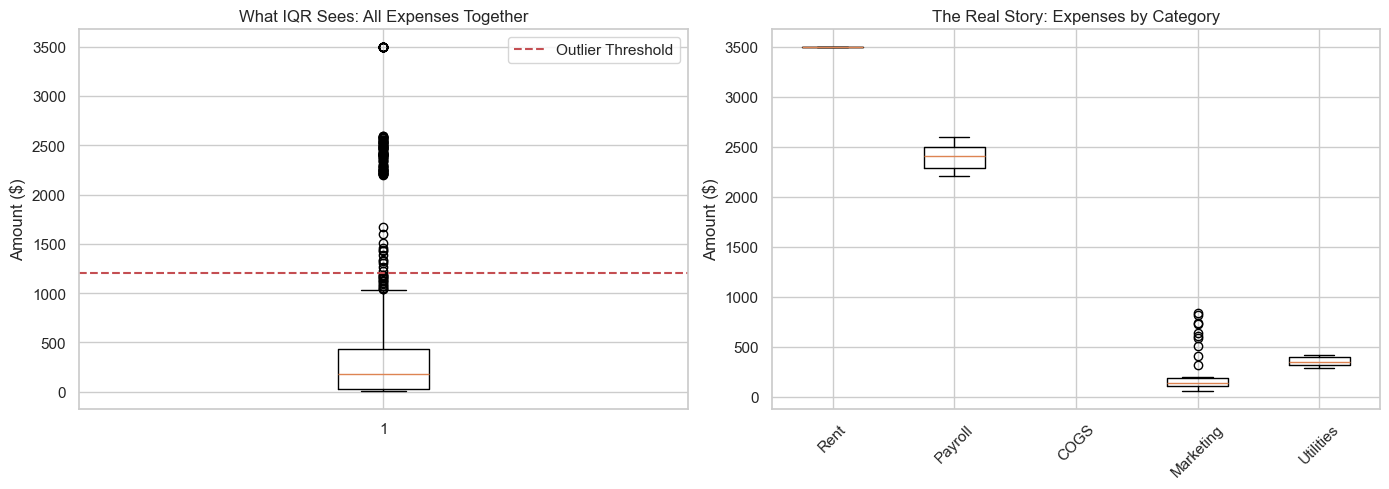

In [87]:
# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: All expenses together 
axes[0].boxplot(expenses['amount'])
axes[0].set_title('What IQR Sees: All Expenses Together')
axes[0].set_ylabel('Amount ($)')
axes[0].axhline(y=1200, color='r', linestyle='--', label='Outlier Threshold')
axes[0].legend()

# Plot 2: Expenses by category
categories = ['Rent', 'Payroll', 'COGS', 'Marketing', 'Utilities']
data_to_plot = [expenses[expenses['category'] == cat]['amount'] for cat in categories]
axes[1].boxplot(data_to_plot, labels=categories)
axes[1].set_title('The Real Story: Expenses by Category')
axes[1].set_ylabel('Amount ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- The 'outliers' aren't errors, they're actually signs of healthy business activity. High COGS days represent our busiest sales periods, rent shows our stable store footprint, and payroll reflects our commitment to staffing during peak times. Removing these would hide the true story of our business performance.

Thus, i'll  retain all the otlier values in the dataset for accurate analysis.

In [88]:
expenses.head()

,date,category,amount,notes
0,2024-01-01,Rent,3500.00,Monthly store rent
1,2024-01-01,Insurance,400.00,Business insurance premium
2,2024-01-01,Software & Subscriptions,150.00,POS and inventory software
3,2024-01-01,Cost of Goods Sold,710.50,Daily COGS
4,2024-01-01,Marketing,723.55,Social media and promotions


In [89]:
expenses.to_csv('expenses_clean_data.csv', index=False)

### Data Cleaning_inventory_csv

In [90]:
inventory.head()

,date,product_id,product_name,category,stock_level,reorder_point,supplier,unit_cost,stock_value
0,2024-01-01,P001,Men's Basic T-shirt,Men,200,40,Urban Threads Co.,7.0,1400.0
1,2024-01-01,P002,Men's Premium T-shirt,Men,200,40,StyleForce Ltd,11.0,2200.0
2,2024-01-01,P003,Men's Slim Jeans,Men,200,40,StyleForce Ltd,18.0,3600.0
3,2024-01-01,P004,Men's Chino Pants,Men,200,40,Urban Threads Co.,15.0,3000.0
4,2024-01-01,P005,Men's Hoodie,Men,200,40,AlphaTex Supplies,22.0,4400.0


In [91]:
inventory.shape

(13675, 9)

In [92]:
inventory.columns

Index(['date', 'product_id', 'product_name', 'category', 'stock_level',
       'reorder_point', 'supplier', 'unit_cost', 'stock_value'],
      dtype='str')

In [93]:
inventory.duplicated().sum()

np.int64(0)

In [94]:
inventory.isnull().sum()

date              0
product_id        0
product_name      0
category          0
stock_level       0
reorder_point     0
supplier          0
unit_cost         0
stock_value      15
dtype: int64

In [95]:
# Fill missing stock_value with calculated values
inventory['stock_value'] = inventory['stock_value'].fillna(
    inventory['stock_level'] * inventory['unit_cost']
)

In [96]:
inventory.isnull().sum()

date             0
product_id       0
product_name     0
category         0
stock_level      0
reorder_point    0
supplier         0
unit_cost        0
stock_value      0
dtype: int64

In [97]:
inventory.dtypes

date                 str
product_id           str
product_name         str
category             str
stock_level        int64
reorder_point      int64
supplier             str
unit_cost        float64
stock_value      float64
dtype: object

In [98]:
inv_str_cols= ['product_id','product_name','category','supplier']

In [99]:
inventory[inv_str_cols] = inventory[inv_str_cols].astype('object')

In [100]:
inventory['date']= pd.to_datetime(inventory['date'])

In [101]:
inventory.dtypes


date             datetime64[us]
product_id               object
product_name             object
category                 object
stock_level               int64
reorder_point             int64
supplier                 object
unit_cost               float64
stock_value             float64
dtype: object

In [102]:
# Check for negative values in numeric columns
negatives = inventory[(inventory['stock_level'] < 0) | 
                      (inventory['unit_cost'] < 0) | 
                      (inventory['stock_value'] < 0)]
print(f"\nNegative values found: {len(negatives)}")
if len(negatives) > 0:
    print(negatives)


Negative values found: 0


In [103]:
# Validate 'stock_value' consistency
inventory['calculated_stock_value'] = inventory['stock_level'] * inventory['unit_cost']
mismatched = inventory[inventory['stock_value'] != inventory['calculated_stock_value']]
print(f"\nMismatched stock values: {len(mismatched)}")
if len(mismatched) > 0:
    print(mismatched[['product_id','stock_value','calculated_stock_value']])


Mismatched stock values: 0


In [104]:
print(inventory['category'].unique())

['Men' 'Women' 'Kids' 'All']


In [105]:
print(inventory['supplier'].unique())

['Urban Threads Co.' 'StyleForce Ltd' 'AlphaTex Supplies'
 'Bella Fabrics Ltd' 'TrendSet Suppliers' 'KidWear Distributors'
 'TinyTrend Co.' 'GlobalGear Wholesale']


In [106]:
inventory = inventory.sort_values(['date', 'product_id']).reset_index(drop=True)

In [107]:
inventory= inventory.drop(['calculated_stock_value'], axis=1)

In [108]:
inventory.describe()

,date,stock_level,reorder_point,unit_cost,stock_value
count,13675,13675.000000,13675.0,13675.000000,13675.000000
mean,2024-09-30 00:00:00,105.014845,40.0,14.420000,1509.847057
min,2024-01-01 00:00:00,40.000000,40.0,2.500000,100.000000
25%,2024-05-16 00:00:00,71.000000,40.0,9.000000,748.000000
50%,2024-09-30 00:00:00,102.000000,40.0,14.000000,1320.000000
75%,2025-02-14 00:00:00,134.000000,40.0,18.000000,2052.000000
max,2025-06-30 00:00:00,200.000000,40.0,35.000000,7000.000000
std,NaN,40.012472,0.0,7.853541,1006.661812


In [109]:
inventory.stock_level.unique()

array([200, 199, 196, 198, 195, 197, 193, 184, 192, 191, 194, 182, 189,
       186, 187, 180, 190, 177, 176, 188, 185, 169, 179, 173, 174, 175,
       161, 178, 165, 172, 168, 150, 158, 171, 181, 166, 167, 138, 159,
       157, 164, 136, 162, 135, 156, 170, 155, 163, 134, 152, 132, 154,
       149, 160, 131, 153, 146, 124, 148, 142, 151, 122, 147, 139, 118,
       145, 116, 114, 141, 137, 111, 143, 144, 101, 133,  97, 128, 140,
        93, 130,  91,  90, 126,  87, 123, 129,  85, 121, 183,  79, 117,
       119,  74, 127, 125,  73, 113,  71, 110, 120, 107,  68, 104,  66,
       103, 115,  99,  65, 108,  95,  61,  92, 102,  94, 105,  56,  89,
       100, 112,  50,  88,  43,  86,  84, 106, 109,  77,  80,  83,  72,
        78,  98,  63,  67,  75,  96,  69,  64,  62,  57,  55,  82,  59,
        76,  53,  58,  81,  51,  52,  49,  48,  54,  60,  46,  45,  42,
        41,  70,  40,  47,  44])

In [110]:
# Select specific columns
inventory_view = inventory[['date', 'product_name', 'stock_level', 'reorder_point']]

# Display the result
print(inventory_view)

            date           product_name  stock_level  reorder_point
0     2024-01-01    Men's Basic T-shirt          200             40
1     2024-01-01  Men's Premium T-shirt          200             40
2     2024-01-01       Men's Slim Jeans          200             40
3     2024-01-01      Men's Chino Pants          200             40
4     2024-01-01           Men's Hoodie          200             40
...          ...                    ...          ...            ...
13670 2025-06-30  Unisex Socks (3-pack)           43             40
13671 2025-06-30           Leather Belt           42             40
13672 2025-06-30        Canvas Tote Bag           62             40
13673 2025-06-30      Men's Swim Shorts           60             40
13674 2025-06-30       Women's Swimsuit          115             40

[13675 rows x 4 columns]


In [ ]:
Handling 

In [111]:
# Calculate day-over-day change
inventory = inventory.sort_values(['product_id', 'date'])
inventory['stock_change'] = inventory.groupby('product_id')['stock_level'].diff()

In [112]:
# Flag large increases (> 50 units)
inventory['is_suspect'] = inventory['stock_change'] > 50
print("Suspicious stock increases found:", inventory['is_suspect'].sum())

Suspicious stock increases found: 136


In [113]:
# Estimate daily sales (stock decreases only)
inventory['daily_sales'] = inventory['stock_change'] * -1

In [114]:
# Remove negative sales (these are stock increases)
inventory['daily_sales'] = inventory['daily_sales'].clip(lower=0)

In [115]:
# Ignore suspicious large increases
inventory.loc[inventory['is_suspect'], 'daily_sales'] = 0

In [116]:
# Example metric
avg_sales = inventory.groupby('product_name')['daily_sales'].mean()

print("\nTop 5 Products by Average Daily Sales:")
print(avg_sales.sort_values(ascending=False).head())


Top 5 Products by Average Daily Sales:
product_name
Canvas Tote Bag          2.624542
Unisex Cap               2.505495
Leather Belt             2.369963
Unisex Socks (3-pack)    2.256410
Men's Chino Pants        1.463370
Name: daily_sales, dtype: float64


In [117]:
inventory.head()

,date,product_id,product_name,category,stock_level,reorder_point,supplier,unit_cost,stock_value,stock_change,is_suspect,daily_sales
0,2024-01-01,P001,Men's Basic T-shirt,Men,200,40,Urban Threads Co.,7.0,1400.0,NaN,False,NaN
25,2024-01-02,P001,Men's Basic T-shirt,Men,199,40,Urban Threads Co.,7.0,1393.0,-1.0,False,1.0
50,2024-01-03,P001,Men's Basic T-shirt,Men,195,40,Urban Threads Co.,7.0,1365.0,-4.0,False,4.0
75,2024-01-04,P001,Men's Basic T-shirt,Men,195,40,Urban Threads Co.,7.0,1365.0,0.0,False,-0.0
100,2024-01-05,P001,Men's Basic T-shirt,Men,195,40,Urban Threads Co.,7.0,1365.0,0.0,False,-0.0


In [119]:
# Replace NaN sales with 0
inventory['daily_sales'] = inventory['daily_sales'].fillna(0)

# Convert -0.0 to 0
inventory['daily_sales'] = inventory['daily_sales'].astype(int)

In [120]:
inventory.head()

,date,product_id,product_name,category,stock_level,reorder_point,supplier,unit_cost,stock_value,stock_change,is_suspect,daily_sales
0,2024-01-01,P001,Men's Basic T-shirt,Men,200,40,Urban Threads Co.,7.0,1400.0,NaN,False,0
25,2024-01-02,P001,Men's Basic T-shirt,Men,199,40,Urban Threads Co.,7.0,1393.0,-1.0,False,1
50,2024-01-03,P001,Men's Basic T-shirt,Men,195,40,Urban Threads Co.,7.0,1365.0,-4.0,False,4
75,2024-01-04,P001,Men's Basic T-shirt,Men,195,40,Urban Threads Co.,7.0,1365.0,0.0,False,0
100,2024-01-05,P001,Men's Basic T-shirt,Men,195,40,Urban Threads Co.,7.0,1365.0,0.0,False,0


In [121]:
inventory.to_csv('inventory_clean_data.csv', index=False)